In [1]:
import numpy as np
import os, sys 
import re
import ROOT
ROOT.gStyle.SetOptStat(0)
import glob
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
from ROOplot import ROOplot

Welcome to JupyROOT 6.28/10


In [2]:
from uncertainties import *
from uncertainties.umath import exp
import math

In [3]:
def is_comment_or_note(row):
    text = " ".join(row.dropna().astype(str)).lower()
    return text.startswith(("comment", "note"))

In [4]:
import requests
import pandas as pd

base_url = "https://confluence.slac.stanford.edu"
page_id = "685801484"

token = "ODgwMzgxNjI5ODYwOnTMXw4tE+Qwks8hSVF5q97RBpdJ"

url = f"{base_url}/rest/api/content/{page_id}?expand=body.storage"

headers = {
    "Authorization": f"Bearer {token}",
    "Accept": "application/json"
}

response = requests.get(url, headers=headers)

data = response.json()
html = data["body"]["storage"]["value"]

df = pd.read_html(html)[-3]

df = df[~df.apply(is_comment_or_note, axis=1)]
df = df.to_dict(orient='list')

/lscratch/perrywar/tmp/ipykernel_3379461/3795069543.py:21: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(html)[-3]


In [5]:
from datetime import datetime, timezone
from zoneinfo import ZoneInfo

dt = datetime.now(ZoneInfo("America/New_York"))

In [6]:
entries = len(df['Timestamp'])

df['Timestamp uncertainty (s)'] = np.array([float(i)*60*60 for i in df['Timestamp uncertainty (h)']])

df['Timestamp'] = np.array([int(datetime.strptime(i, "%Y-%m-%d %H:%M").replace(tzinfo=ZoneInfo("America/New_York")).timestamp()) for i in df['Timestamp']])
df['Timestamp'] = np.array([ufloat(df['Timestamp'][i], df['Timestamp uncertainty (s)'][i]) for i in range(entries)])

for key in ['Activity (crystal)', 'Ventilation rate (crystal)', 'Surface-Volume ratio (crystal)']:
    df[key] = np.array([ufloat_fromstr(i) for i in df[key]])

In [7]:
end_date = "2026-03-06 00:00" # date up to which we would like to measure activity

In [8]:
crystal = {}
entries = len(df['Timestamp'])

crystal['ts'] = df['Timestamp']

crystal['elapsed'] = [(crystal['ts'][i+1] - crystal['ts'][i]) for i in range(entries-1)]
crystal['elapsed'].append(ufloat(int(datetime.strptime(end_date, "%Y-%m-%d %H:%M").replace(tzinfo=ZoneInfo("America/New_York")).timestamp()), 0) - crystal['ts'][-1])
crystal['elapsed'] = np.array(crystal['elapsed'])

crystal['A0'] = df['Activity (crystal)']
crystal['lambda_v'] = df['Ventilation rate (crystal)']
crystal['SV'] = df['Surface-Volume ratio (crystal)']
crystal['location'] = df['Location']

In [9]:
housing = {}
start_entry = 73 # row index where packaging started
entries = len(df['Timestamp'][start_entry:]) # ignore rows where we didn't have housing information

housing['ts'] = df['Timestamp'][start_entry:]

housing['elapsed'] = [(housing['ts'][i+1] - housing['ts'][i]) for i in range(entries-1)]
housing['elapsed'].append(ufloat(int(datetime.strptime(end_date, "%Y-%m-%d %H:%M").replace(tzinfo=ZoneInfo("America/New_York")).timestamp()), 0) - housing['ts'][-1])
housing['elapsed'] = np.array(housing['elapsed'])

housing['A0'] = np.array([ufloat_fromstr(i) for i in df['Activity (housing)'][start_entry:]])
housing['lambda_v'] = np.array([ufloat_fromstr(i) for i in df['Ventilation rate (housing)'][start_entry:]])
housing['SV'] = np.array([ufloat_fromstr(i) for i in df['Surface-Volume ratio (housing)'][start_entry:]])
housing['location'] = df['Location'][start_entry:]

# insert an initial entry where the freshly-etched housing was put into a purge box before packaging
storage_date = "2019-03-27 00:00"
housing['ts'] = np.insert(housing['ts'], 0, ufloat(int(datetime.strptime(storage_date, "%Y-%m-%d %H:%M").replace(tzinfo=ZoneInfo("America/New_York")).timestamp()), 60*60*24))
housing['elapsed'] = np.insert(housing['elapsed'], 0, housing['ts'][1] - housing['ts'][0])
housing['A0'] = np.insert(housing['A0'], 0, ufloat(0.01, 0.01))
housing['lambda_v'] = np.insert(housing['lambda_v'], 0, ufloat(0.8, 0.3))
housing['SV'] = np.insert(housing['SV'], 0, ufloat(3, 1))
housing['location'] = np.insert(housing['location'], 0, 'Purged storage')

In [10]:
# assume that lambda_a = 0 in these clean room environments
# referencing www.chemlin.org for half lives and uncertainties
tau_0 = ufloat(3.8222, 0.0009)*24 / np.log(2) # Rn222 lifetime [h]
lambda_0 = 1 / tau_0                          # Rn222 decay constant [/h]
tau_1 = ufloat(3.097, 0.012)/60 / np.log(2)   # Po218 lifetime [h]
lambda_1 = 1 / tau_1                          # Po218 decay constant [/h]
tau_2 = ufloat(27.06, 0.07)/60 / np.log(2)    # Pb214 lifetime [h]
lambda_2 = 1 / tau_2                          # Pb214 decay constant [/h]
tau_3 = ufloat(19.71, 0.02)/60 / np.log(2)    # Bi214 lifetime [h]
lambda_3 = 1 / tau_3                          # Bi214 decay constant [/h]

# using the typical value in Knutson for deposition velocity
v_d = ufloat(10, 2) # m / h

The balance equation for Po218 concentration in the air is $\lambda_1 A_0 = (\lambda_1 + \lambda_v + \lambda_d) A_1$

The balance equation for Po218 concentration on a surface is $\lambda_d A_1 = \lambda_1 A_1^{S*}$

The balance equation for Pb214 concentration in the air is $\lambda_2 A_1 = (\lambda_2 + \lambda_v + \lambda_d) A_2$

The balance equation for Pb214 concentration on a surface is $\lambda_2 A_1^{S*} + \lambda_d A_2 = \lambda_2 A_2^{S*}$

In [11]:
def calc_implantation_rate(A_0, lambda_v, SV, frac_implanted=ufloat(0.558, 0.024)):

    lambda_d = SV * v_d # /h
    
    #### Steady-state of Po-218 in air
    # source: decay of Rn-222 in air
    # sinks: decay of Po-218 in air, ventilation, deposition
    A_1 = lambda_1 * A_0 / (lambda_1 + lambda_v + lambda_d)

    #### Steady-state of Po-218 on surfaces
    # source: deposition of airborne Po-218
    # sinks: decay of deposited Po-218 on surfaces
    A_1_s = lambda_d * A_1 / lambda_1

    #### Steady-state of Pb-214 in air
    # source: decay of Po-218 in air
    # sinks: decay of Pb-214 in air, ventilation, deposition
    A_2 = lambda_2 * A_1 / (lambda_2 + lambda_v + lambda_d)

    #### Steady-state of Pb-214 on surfaces
    # source: decay of Po-218 on surfaces, deposition of airborne Pb-214
    # sinks: decay of Pb-214 on surfaces
    A_2_s = (lambda_2 * A_1_s + lambda_d * A_2) / lambda_2

    #### Steady-state of Bi-214 in air
    # source: decay of Pb-214 in air
    # sinks: decay of Bi-214 in air, ventilation, deposition
    A_3 = lambda_3 * A_2 / (lambda_3 + lambda_v + lambda_d)
    
    #### Steady-state of Bi-214 on surfaces
    # source: decay of Pb-214 on surfaces, deposition of airborne Bi-214
    # sinks: decay of Bi-214 on surfaces
    A_3_s = (lambda_3 * A_2_s + lambda_d * A_3) / lambda_3


    #### Of the Pb-214 nuclei on surfaces, only a fraction implant into a surface
    #### due to the recoil of its decay or the previous decay
    R_implanted = A_3_s * frac_implanted / SV # convert from volume-equivalent activity to surface activity
    
    return R_implanted

In [12]:
#Pb210 radioactive properties
y2s = 3.154e7
s2month = 3.80517e-7
s2day = 1.157e-5

Pb210_halflife = (ufloat(22.20, 0.22)*y2s) # s
Pb210_lifetime = Pb210_halflife / np.log(2) # s
Pb210_lambda   = 1 / Pb210_lifetime

$N_{\text{Pb-210}} = N_0 \text{exp}(-\lambda_{\text{Pb-210}} T) + \int_0^T R_{\text{implanted}} \cdot \text{exp}(-\lambda_{\text{Pb-210}} (T - t)) dt$

$N_{\text{Pb-210}} = N_0 \text{exp}(-\lambda_{\text{Pb-210}} T) + R \frac{1 - \text{exp}(-\lambda_{\text{Pb-210}} T)}{\lambda_{\text{Pb-210}}}$

In [13]:
# find total implanted Pb-210 taking into account its decay
# t from t0 to T
def integrate_decays(R, N0, T):
    return R*(1 - exp(-Pb210_lambda * T))/Pb210_lambda + N0 * exp(-Pb210_lambda * T)

In [14]:
# find total implanted Pb-210 taking into account its decay
# t from t0 to T
def integrate_decays_nominal(R, N0, T):
    T = np.array([i.nominal_value for i in T])
    R = R.nominal_value
    N0 = N0.nominal_value
    return R*(1 - np.exp(-Pb210_lambda.nominal_value * T))/Pb210_lambda.nominal_value + N0 * np.exp(-Pb210_lambda.nominal_value * T)

RSF Lab
28+/-14
1760456400.0


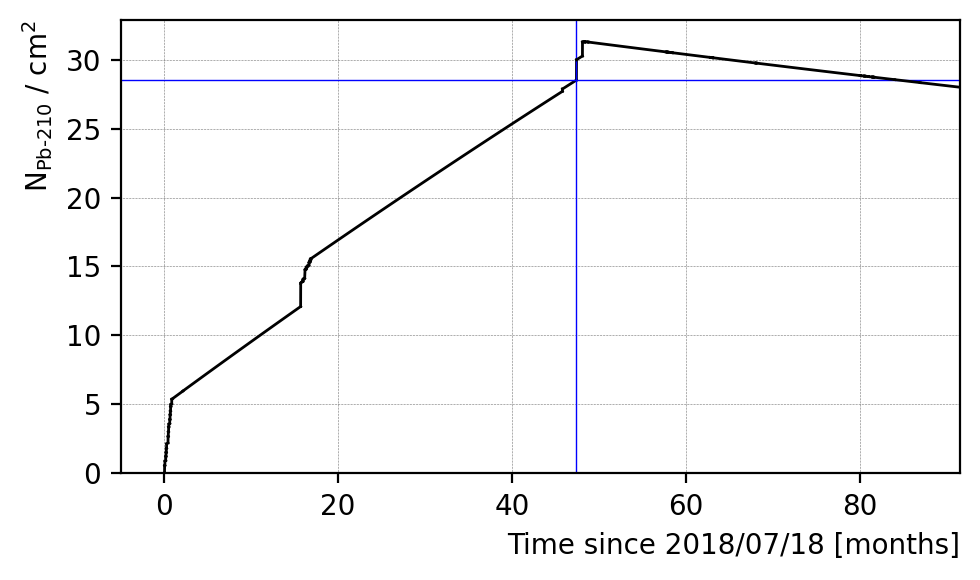

In [60]:
# initial number of implanted Pb-210
N0 = ufloat(0, 0)
t_crystal = []
N_crystal = []

# Window for plotting
window_start = crystal['ts'][0].nominal_value
window_end = datetime(2026, 3, 3, 0, 0, 0).replace(tzinfo=ZoneInfo("America/New_York")).timestamp()

plt.figure(figsize=(5,3), dpi=200)

for i in range(len(crystal['ts'])): # polishing timestamps end at i=39
    location, A_0, lambda_v, SV = crystal["location"][i], crystal["A0"][i], crystal["lambda_v"][i], crystal["SV"][i]
    R_implanted = calc_implantation_rate(A_0, lambda_v, SV) # Pb-214 decays / s / m^2

    # number of implanted nuclei (N) vs. time (t)
    t0 = crystal['ts'][i]
    tf = t0 + crystal['elapsed'][i]
    if location.lower() == 'suf polishing (tunnel a)': # crystal only exposed to air 5% of the time
        Nf = integrate_decays(R_implanted, N0, (tf - t0)*0.05)
    elif location.lower() == 'b04 lab': # crystal only exposed to air for 5-10 min or about 0.5% of the time.
        Nf = integrate_decays(R_implanted, N0, (tf - t0)*0.005)
    elif location.lower() == 'snf lab (fab)': # crystal only exposed to air for 6 hrs or about 8% of the time.
        Nf = integrate_decays(R_implanted, N0, (tf - t0)*0.08)
    else:
        Nf = integrate_decays(R_implanted, N0, tf - t0)

    # use nominal values for plotting
    t = np.linspace(t0.nominal_value, tf.nominal_value, 100)
    if location.lower() == 'suf polishing (tunnel a)': # crystal only exposed to air 5% of the time
        N = integrate_decays_nominal(R_implanted, N0, (t - t0)*0.05)
    elif location.lower() == 'b04 lab': # crystal only exposed to air for 5-10 min or about 0.5% of the time.
        N = integrate_decays_nominal(R_implanted, N0, (t - t0)*0.005)
    elif location.lower() == 'snf lab (fab)': # crystal only exposed to air for 6 hrs or about 8% of the time.
        N = integrate_decays_nominal(R_implanted, N0, (t - t0)*0.08)
    else:
        N = integrate_decays_nominal(R_implanted, N0, t - t0)
    t_crystal.append((t - window_start)*s2month)
    N_crystal.append(N*1e-4)

    #### plot implanted nuclei vs. time at start of window ####
    plt.plot((t - window_start)*s2month, N*1e-4, color = 'black', lw = 1)
    if i == 73:
        print(location)
        plt.axvline((t0.nominal_value - window_start)*s2month, 0, 1, lw = 0.5, color = 'b')
        plt.axhline(N0.nominal_value*1e-4, 0, 1, lw = 0.5, color = 'b')
        
    if location=='Vacuum SNOBOX':
        print(Pb210_lambda*1e9*N0*1e-4)
        print(t0.nominal_value)
    
    N0 = Nf

plt.xlim(-5, (window_end-window_start)*s2month)
plt.ylim(0, None)
plt.grid(True, color = 'black', lw = 0.2, ls = 'dotted')
plt.xlabel(f'Time since {datetime.fromtimestamp(window_start).strftime("%Y/%m/%d")} [months]', loc = 'right')
plt.ylabel(r'N$_{\text{Pb-210}}$ / cm$^2$', loc = 'top')
plt.tight_layout()

t_crystal = np.concatenate(t_crystal)
N_crystal = np.concatenate(N_crystal)

#plt.savefig("G157_hist.png")

27+/-19
Vacuum SNOBOX


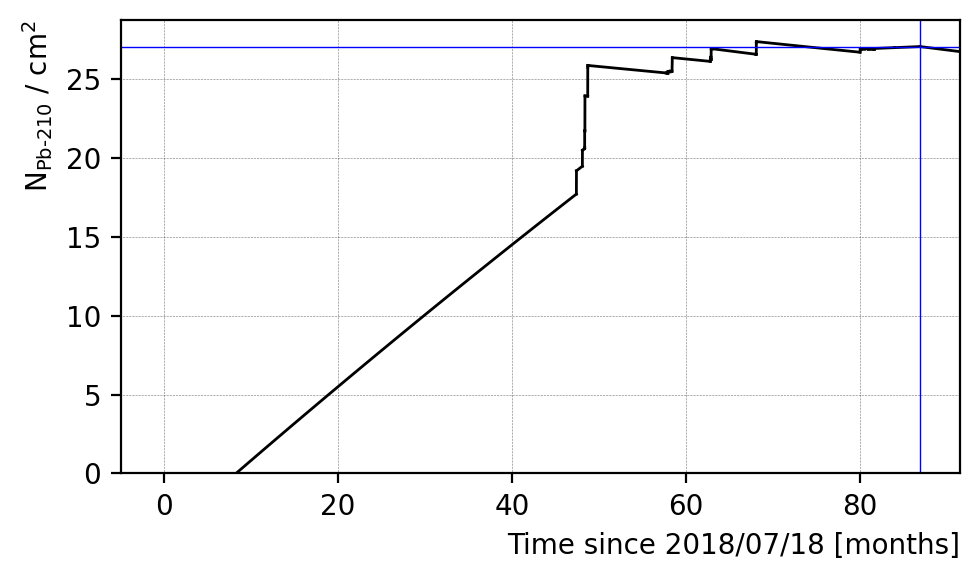

In [139]:
# initial number of implanted Pb-210
N0 = ufloat(0, 0)
t_housing = []
N_housing = []

# Window for plotting
window_start = crystal['ts'][0].nominal_value
window_end = datetime(2026, 3, 3, 0, 0, 0).replace(tzinfo=ZoneInfo("America/New_York")).timestamp()

plt.figure(figsize=(5,3), dpi=200)

for i in range(len(housing['ts'])):
    location, A_0, lambda_v, SV = housing["location"][i], housing["A0"][i], housing["lambda_v"][i], housing["SV"][i]
    R_implanted = calc_implantation_rate(A_0, lambda_v, SV) # Pb-214 decays / s / m^2

    # number of implanted nuclei (N) vs. time (t)
    t0 = housing['ts'][i]
    tf = t0 + housing['elapsed'][i]
    Nf = integrate_decays(R_implanted, N0, tf - t0)

    # use nominal values for plotting
    t = np.linspace(t0.nominal_value, tf.nominal_value, 100)
    N = integrate_decays_nominal(R_implanted, N0, t - t0)
    t_housing.append((t - window_start)*s2month)
    N_housing.append(N*1e-4)

    #### plot implanted nuclei vs. time at start of window ####
    plt.plot((t - window_start)*s2month, N*1e-4, color = 'black', lw = 1)
    if i == 107:
        print(location)
        plt.axvline((t0.nominal_value - window_start)*s2month, 0, 1, lw = 0.5, color = 'b')
        plt.axhline(N0.nominal_value*1e-4, 0, 1, lw = 0.5, color = 'b')
        
    if location=='CUTE Vacuum':
        print(Pb210_lambda*N0*1e-4*1e9)
    N0 = Nf

plt.xlim(-5, (window_end-window_start)*s2month)
plt.ylim(0, None)
plt.grid(True, color = 'black', lw = 0.2, ls = 'dotted')
plt.xlabel(f'Time since {datetime.fromtimestamp(window_start).strftime("%Y/%m/%d")} [months]', loc = 'right')
plt.ylabel(r'N$_{\text{Pb-210}}$ / cm$^2$', loc = 'top')
plt.tight_layout()

t_housing = np.concatenate(t_housing)
N_housing = np.concatenate(N_housing)

#plt.savefig("G157_hist.png")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


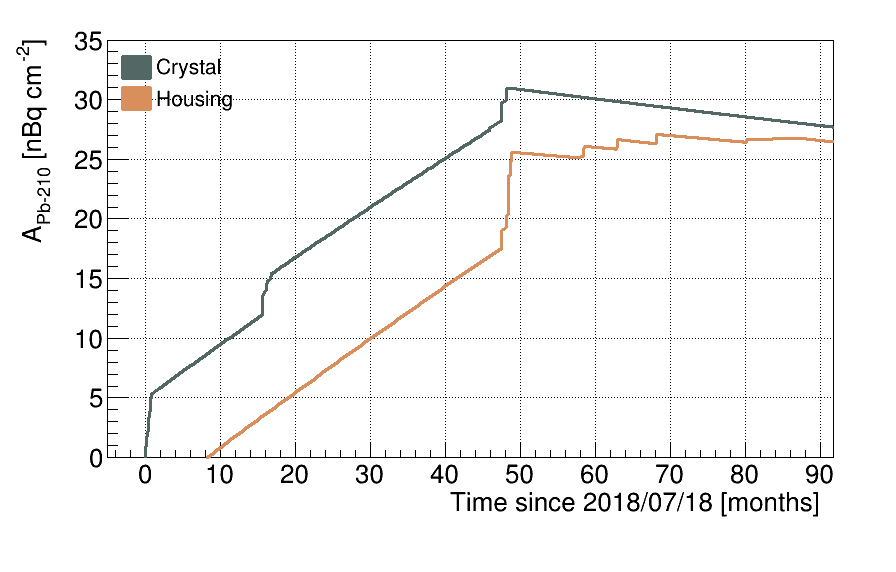

In [23]:
plot = ROOplot(_width=900, _height=600, _xlabel=f'Time since {datetime.fromtimestamp(window_start).strftime("%Y/%m/%d")} [months]', 
               _ylabel="A_{Pb-210} [nBq cm^{-2}]", _leftMargin=0.12, _rightMargin=0.07,
               _xlim=True, _xlow = -5, _xhigh=max(t_crystal),
               _ylim=True, _ylow = 0, _yhigh = 35)
color_crystal = ROOT.TColor.GetColor('#536765')
color_housing = ROOT.TColor.GetColor('#D98F5C')
plot.createScatter(t_crystal, Pb210_lambda.nominal_value * N_crystal * 1e9, color = color_crystal, width=3, label = 'Crystal')
plot.createScatter(t_housing, Pb210_lambda.nominal_value * N_housing * 1e9, color = color_housing, width=3, label = 'Housing')

graphs = plot.getGraphs()
plot.draw("AL", "L ", grid=True)

legend = ROOT.TLegend(0.13, 0.8, 0.5, 0.91)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.SetTextSize(0.04)
legend.SetEntrySeparation(0.01)
legend.SetMargin(0.12)

legend.Draw()

In [24]:
from CDMSDataCatalog import CDMSDataCatalog
from cats.cdataframe import CDataFrame

In [25]:
# Z1 low bg 50V
series_list=['23240109_075338', '23240109_021236', 
'23240108_203134', '23231221_101235', 
'23231221_015705', '23231220_190923', 
'23231220_122140', '23231220_053358', 
'23231220_012745', '23231219_184002', 
'23231219_110331', '23231219_034952', 
'23231218_223530', '23231218_190035', 
'23231218_152721', '23231218_093255', 
'23231218_024511', '23231217_212512', 
'23231217_171613', 
'23231217_135018', '23231216_233807', 
'23231216_211119', '23231216_194929', 
'23231216_182937', '23231216_173436', 
'23231216_145300', '23231216_100125', 
'23231216_043946', '23231216_013604'] # Ge calibration

In [26]:
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [27]:
## Use DataCat to pull the series
dc = CDMSDataCatalog().findData(
    Facility    = "CUTE",
    nFridgeRun  = 37,
    Series      = series_list,
    ProdTag     = ProdTag,
    nMergeLevel = 1,
    dofetch     = True
)
filepath = [x.filePath for x in dc]

In [28]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), filepath, friends = [[x+":rqDir/eventTree" for x in filepath]])

In [29]:
RQs = (["SeriesNumber", "PTOFamps", "EventNumber", "EventTime"])
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(det), "PTOFamps>0"])
df_rqs = df_filtered.AsNumpy(RQs)

In [37]:
N0 = ufloat(30, 15) # atoms / cm^2
t0 = ufloat(1697743380, 900) # timestamp in unix eastern

#### track change in number of Ge-71 nuclei during and after exposures ####
N_tot = 0
for sn in np.unique(df_rqs['SeriesNumber']):
    snCut = df_rqs['SeriesNumber'] == sn
    evtTimes = df_rqs['EventTime'][snCut]
    sn_start = min(evtTimes)
    sn_end = max(evtTimes)

    N_start = N0 * exp(-Pb210_lambda * (sn_start - t0))
    N_end = N0 * exp(-Pb210_lambda * (sn_end - t0))

    N_tot += N_start - N_end
    print(f'{sn}: {N_tot}')

print()
print('{:+.3uS} total Pb-210 events'.format(N_tot*261.79) )

23231216013604.0: 0.00029+/-0.00015
23231216043946.0: 0.0008+/-0.0004
23231216100125.0: 0.0009+/-0.0004
23231216145300.0: 0.0012+/-0.0006
23231216173436.0: 0.0013+/-0.0006
23231216182937.0: 0.0014+/-0.0007
23231216194929.0: 0.0014+/-0.0007
23231216211119.0: 0.0015+/-0.0008
23231216233807.0: 0.0016+/-0.0008
23231217135018.0: 0.0019+/-0.0009
23231217171613.0: 0.0023+/-0.0011
23231217212512.0: 0.0028+/-0.0014
23231218024511.0: 0.0035+/-0.0017
23231218093255.0: 0.0039+/-0.0020
23231218152721.0: 0.0042+/-0.0021
23231218190035.0: 0.0044+/-0.0022
23231218223530.0: 0.0049+/-0.0025
23231219034952.0: 0.0057+/-0.0029
23231219110331.0: 0.0064+/-0.0032
23231219184002.0: 0.007+/-0.004
23231220012745.0: 0.008+/-0.004
23231220053358.0: 0.008+/-0.004
23231220122140.0: 0.009+/-0.004
23231220190923.0: 0.010+/-0.005
23231221015705.0: 0.010+/-0.005
23231221101235.0: 0.010+/-0.005
23240108203134.0: 0.011+/-0.005
23240109021236.0: 0.011+/-0.006
23240109075338.0: 0.012+/-0.006

+3.01(1.51) total Pb-210 events

In [38]:
ufloat(3, 1.5) / ufloat(4669, 813)

0.000642535874919683+/-0.0003401924314561745